# Day 1 — LeafGuard EDA

Run this on **Kaggle** with the `emmarex/plantdisease` dataset added (Add Data -> search `plantdisease`).

Goal: understand class distribution, image sizes, and look at sample images before writing any training code.

In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    if files:
        print("  Sample files:", files[:3])

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/emmarex
/kaggle/input/datasets/emmarex/plantdisease
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Pepper__bell___Bacterial_spot
  Sample files: ['0f72db9c-d635-4415-9781-68937328aed2___NREC_B.Spot 9188.JPG', '1b8d3e98-43d9-441d-93ef-a359e6e9ddc2___NREC_B.Spot 9052.JPG', 'b6d35d21-4812-4e32-ab9a-b6ddda8cbb79___JR_B.Spot 8972.JPG']
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Potato___healthy
  Sample files: ['7948ada9-eabc-4cb7-a579-b73e938eb716___RS_HL 4185.JPG', 'f5bd2732-197b-4d8e-bb50-a4966dc416f5___RS_HL 1840.JPG', '5a3fc4bb-a78c-4276-8934-f0b037ffb860___RS_HL 5412.JPG']
/kaggle/input/datasets/emmarex/plantdisease/PlantVillage/Tomato_Leaf_Mold
  Sample files: ['74cb417c-24ca-43b2-897a-8c310636ac22___Crnl_L.Mold 7149.JPG', '05205449-e0d0-4d2f-a2fb-6f1fc0e2e9c5___Crnl_L.Mold 8717.JPG', '16cf47c0-abb4-47e3-bab3-4a7c6348b7ab___Crnl_L.Mold 6995.JPG'

In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

DATA_ROOT = "/kaggle/input/datasets/emmarex/plantdisease/PlantVillage"

OUT_DIR = Path("/kaggle/working/outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Exists:", os.path.exists(DATA_ROOT))

Exists: True


In [3]:
from pathlib import Path

def list_classes(root):
    """Return sorted class folder names."""
    root_path = Path(root)

    if not root_path.exists():
        raise FileNotFoundError(f"Dataset root not found: {root}")

    return sorted(
        p.name for p in root_path.iterdir()
        if p.is_dir()
    )


def dataset_stats(root):
    """Count images per class."""
    root_path = Path(root)
    stats = {}

    for cls in list_classes(root):
        cls_dir = root_path / cls

        n = sum(
            1 for f in cls_dir.iterdir()
            if f.suffix.lower() in {".jpg", ".jpeg", ".png"}
        )

        stats[cls] = n

    return stats


def imbalance_ratio(stats):
    """Ratio of largest class to smallest class."""
    if not stats:
        raise ValueError("stats dict is empty")

    counts = list(stats.values())
    return round(max(counts) / min(counts), 2)


def top_n_classes(stats, n=5, largest=True):
    """Return largest or smallest classes."""
    if n <= 0:
        raise ValueError("n must be positive")

    ordered = sorted(
        stats.items(),
        key=lambda kv: kv[1],
        reverse=largest
    )

    return ordered[:n]

In [4]:
classes = list_classes(DATA_ROOT)

print(f"{len(classes)} classes:")

for c in classes:
    print(" -", c)

15 classes:
 - Pepper__bell___Bacterial_spot
 - Pepper__bell___healthy
 - Potato___Early_blight
 - Potato___Late_blight
 - Potato___healthy
 - Tomato_Bacterial_spot
 - Tomato_Early_blight
 - Tomato_Late_blight
 - Tomato_Leaf_Mold
 - Tomato_Septoria_leaf_spot
 - Tomato_Spider_mites_Two_spotted_spider_mite
 - Tomato__Target_Spot
 - Tomato__Tomato_YellowLeaf__Curl_Virus
 - Tomato__Tomato_mosaic_virus
 - Tomato_healthy


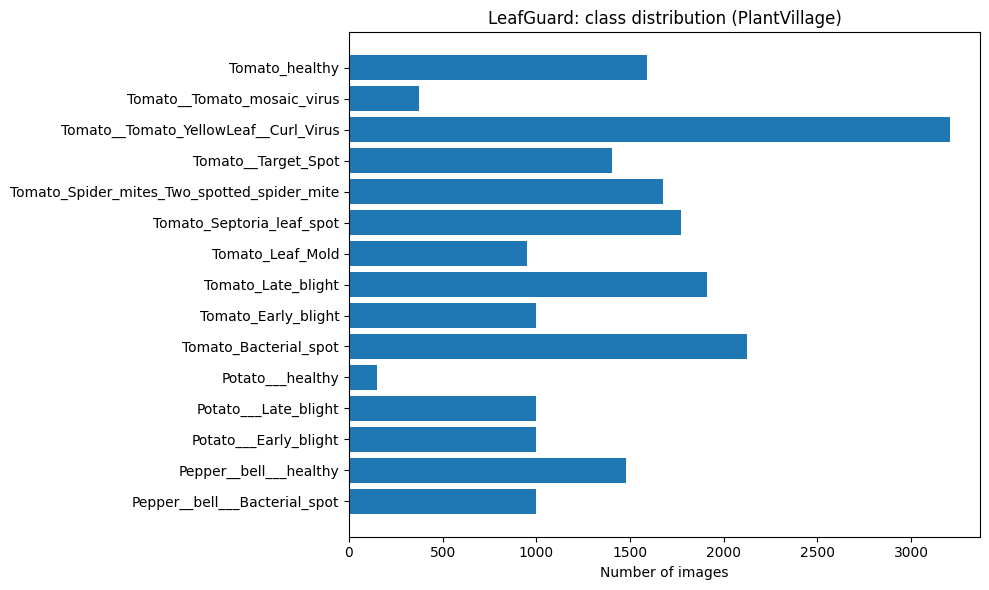

Total images: 20638
Min class size: 152 | Max class size: 3208
Imbalance ratio (max/min): 21.11


In [5]:
stats = dataset_stats(DATA_ROOT)

fig, ax = plt.subplots(figsize=(10, 6))
names = list(stats.keys())
counts = list(stats.values())
ax.barh(names, counts)
ax.set_xlabel("Number of images")
ax.set_title("LeafGuard: class distribution (PlantVillage)")
fig.tight_layout()
fig.savefig(OUT_DIR / "class_distribution.png", dpi=150)
plt.show()

print("Total images:", sum(counts))
print("Min class size:", min(counts), "| Max class size:", max(counts))
print("Imbalance ratio (max/min):", round(max(counts) / min(counts), 2))

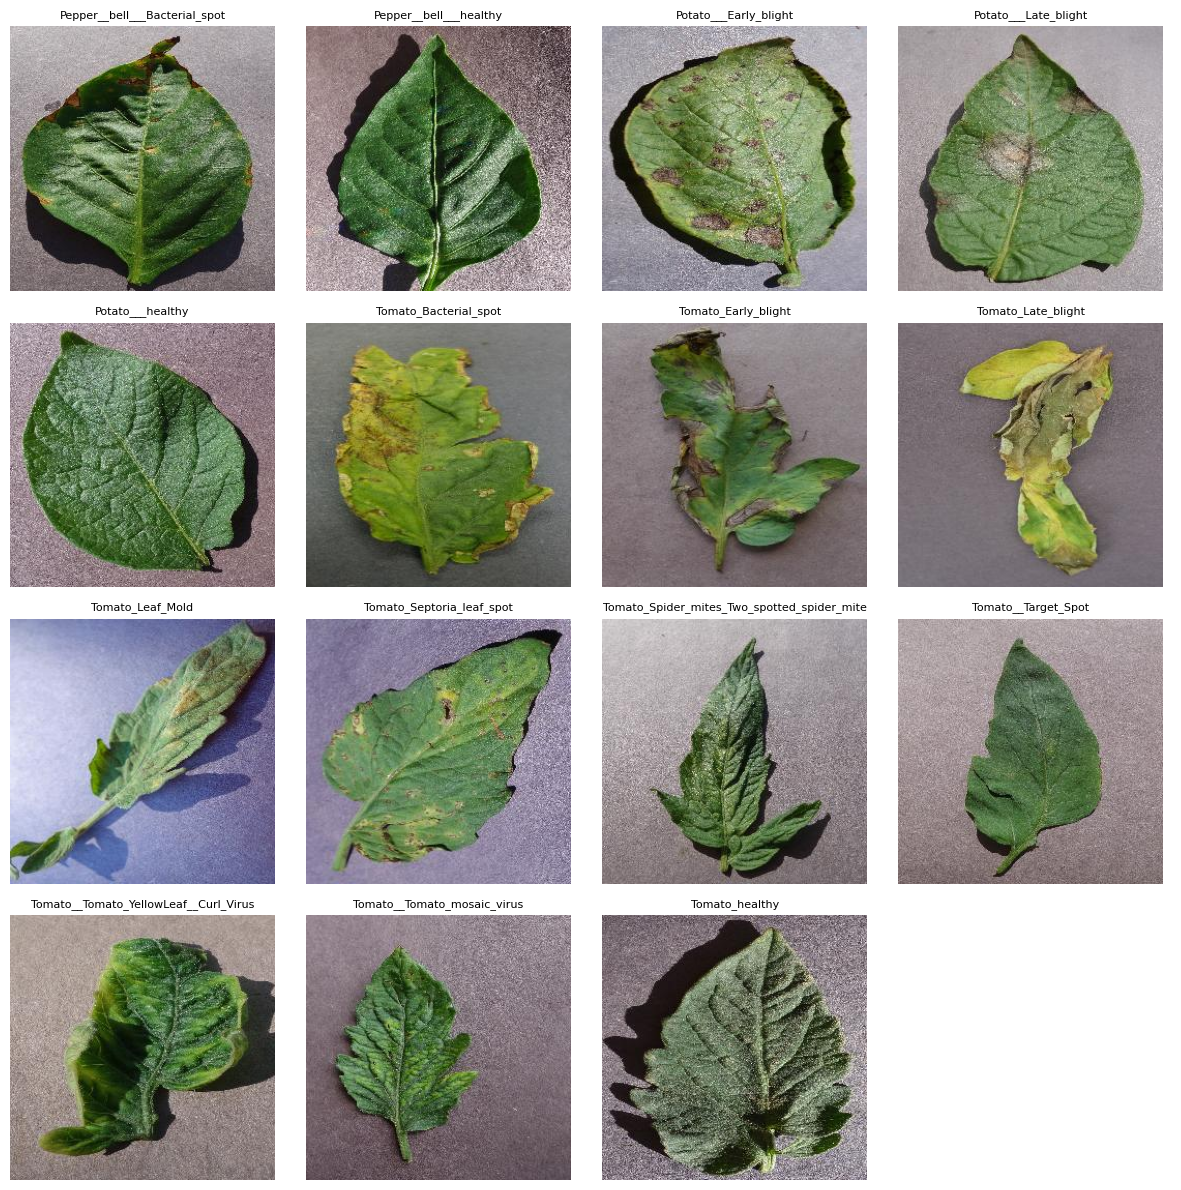

In [6]:
# Sample grid: one random image per class
import random

n = len(classes)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_dir = Path(DATA_ROOT) / cls
    img_path = random.choice(list(cls_dir.glob("*.jpg")) + list(cls_dir.glob("*.JPG")) + list(cls_dir.glob("*.png")))
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=8)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.tight_layout()
fig.savefig(OUT_DIR / "sample_grid.png", dpi=150)
plt.show()

In [7]:
# Image size distribution (quick sample of 200 random images)
all_images = []
for cls in classes:
    all_images.extend((Path(DATA_ROOT) / cls).glob("*"))

sample = random.sample(all_images, min(200, len(all_images)))
sizes = [Image.open(p).size for p in sample]
widths, heights = zip(*sizes)

print("Width  -- min/median/max:", min(widths), sorted(widths)[len(widths)//2], max(widths))
print("Height -- min/median/max:", min(heights), sorted(heights)[len(heights)//2], max(heights))

Width  -- min/median/max: 256 256 256
Height -- min/median/max: 256 256 256


## Findings (fill this in after running)

- Number of classes:
- Total images:
- Class imbalance ratio:
- Typical image size (so we know what to resize to in `get_dataloaders`):
- Anything surprising in the sample grid (blurry images, watermarks, background clutter)?

Copy this into `docs/notes/week1.md` (create the file) when you write up the Week 1 findings on Day 5.